# Isolation Forest Outlier Detection

Isolation Forest isolates anomalies by recursively partitioning features. Since anomalies require fewer random splits to isolate, they lie closer to the root of isolation trees. This notebook generates clustered inliers (normal coordinates) and random outliers (anomalies), fits an Isolation Forest model, and visualizes the anomaly scoring contour maps using Matplotlib.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Generate synthetic 2D data (350 clustered normal points, 50 random noise anomalies)
np.random.seed(65)

# Normal inliers (centered clusters)
X_inliers_1 = np.random.normal(2, 0.6, (175, 2))
X_inliers_2 = np.random.normal(-2, 0.6, (175, 2))
X_inliers = np.vstack((X_inliers_1, X_inliers_2))

# Anomalous outliers (random uniform spread)
X_outliers = np.random.uniform(-5, 5, (50, 2))

# Combine datasets
X = np.vstack((X_inliers, X_outliers))
y = np.concatenate((np.ones(350), -np.ones(50))) # 1 = inlier, -1 = outlier

df = pd.DataFrame(X, columns=['X_Coord', 'Y_Coord'])
df['Label'] = y.astype(int)
df.head(10)



,X_Coord,Y_Coord,Label
0,1.499801,1.674727,1
1,1.483896,1.698922,1
2,2.608019,2.446342,1
3,1.044143,2.052651,1
4,2.019936,1.058300,1
5,2.108643,1.353374,1
6,3.205017,1.879278,1
7,1.568009,2.307948,1
8,1.846341,1.892487,1
9,1.862589,2.102577,1


## Isolation Forest Training & Anomaly Evaluation

We fit an Isolation Forest model to our coordinates set, specifying a contamination level matching the actual outlier proportion (12.5%).



In [2]:
# Train Isolation Forest
model = IsolationForest(contamination=0.125, random_state=42)
model.fit(X)

# Predict labels (-1 = outlier, 1 = inlier)
y_pred = model.predict(X)

# Calculate anomaly detection accuracy
from sklearn.metrics import classification_report
print("Outlier Detection Classification Report:")
print(classification_report(y, y_pred, target_names=['Anomaly', 'Normal']))



Outlier Detection Classification Report:
              precision    recall  f1-score   support

     Anomaly       0.80      0.80      0.80        50
      Normal       0.97      0.97      0.97       350

    accuracy                           0.95       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.95      0.95      0.95       400



## Outlier Scoring Contour Visualization

We build a coordinates grid, calculate the model anomaly score at each cell, and render the resulting classification boundary and decision contour gradient using Matplotlib.



<cell>:29: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



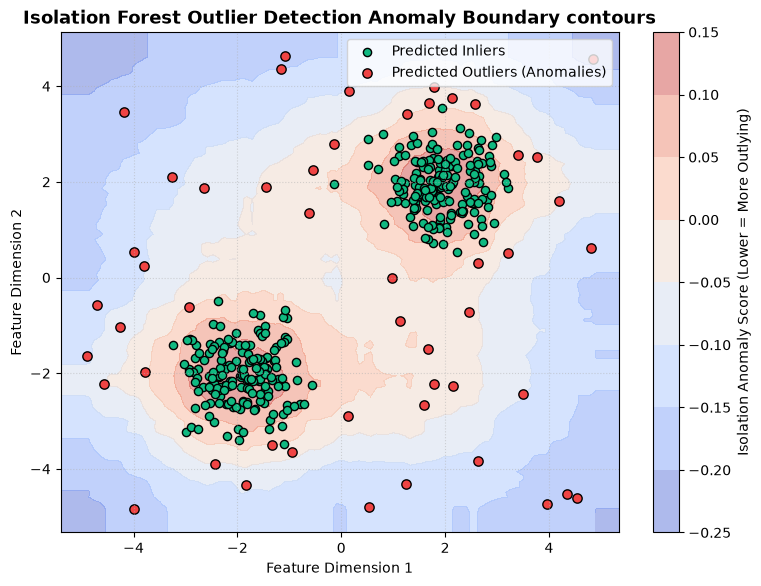

In [3]:
fig, ax = plt.subplots(figsize=(9, 6.5))

# Generate grid points
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Calculate decision scores (lower score = more anomalous)
scores = model.decision_function(grid_points)
scores = scores.reshape(xx.shape)

# Draw filled contour scores
contour = ax.contourf(xx, yy, scores, cmap='coolwarm', alpha=0.45)
fig.colorbar(contour, ax=ax, label='Isolation Anomaly Score (Lower = More Outlying)')

# Scatter normal predictions vs anomaly predictions
inlier_indices = y_pred == 1
outlier_indices = y_pred == -1

ax.scatter(X[inlier_indices, 0], X[inlier_indices, 1], c='#10B981', label='Predicted Inliers', edgecolors='k', s=35)
ax.scatter(X[outlier_indices, 0], X[outlier_indices, 1], c='#EF4444', label='Predicted Outliers (Anomalies)', edgecolors='k', s=45)

ax.set_title('Isolation Forest Outlier Detection Anomaly Boundary contours', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Dimension 1')
ax.set_ylabel('Feature Dimension 2')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)
plt.show()
